Imports et chargements

Ce bloc charge les bibliothèques nécessaires et lit les datasets Maths et Portugais pour l'analyse KNN.

In [13]:
import os
os.environ['OMP_NUM_THREADS'] = '2'

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_mat = pd.read_csv("../dataset/student-mat.csv")

df_por = pd.read_csv("../dataset/student-por.csv")

print("Math dataset :", df_mat.shape)
print("Portuguese dataset :", df_por.shape)

Math dataset : (395, 33)
Portuguese dataset : (649, 33)


Création des classes

Ce code transforme la note finale G3 en trois classes de performance (Echec, Moyen, Bon) pour la classification.

In [14]:
def niveau(note):

    if note < 10:
        return "Echec"

    elif note < 14:
        return "Moyen"

    else:
        return "Bon"

df_mat["niveau"] = df_mat["G3"].apply(niveau)

df_por["niveau"] = df_por["G3"].apply(niveau)

KNN sur les deux datasets

Ce bloc entraîne un classifieur KNN sur les deux datasets et stocke les prédictions pour comparer les performances.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler


knn_results = {}

for name, df in [("Math", df_mat), ("Portuguese", df_por)]:

    X = pd.get_dummies(df.drop(columns=["niveau"]), drop_first=True)

    y = df["niveau"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    knn_results[name] = {
        "y_test": y_test,
        "y_pred": y_pred
    }

Matrices confusion KNN

Ce code affiche les matrices de confusion pour chaque dataset afin de visualiser les erreurs de classification par classe.

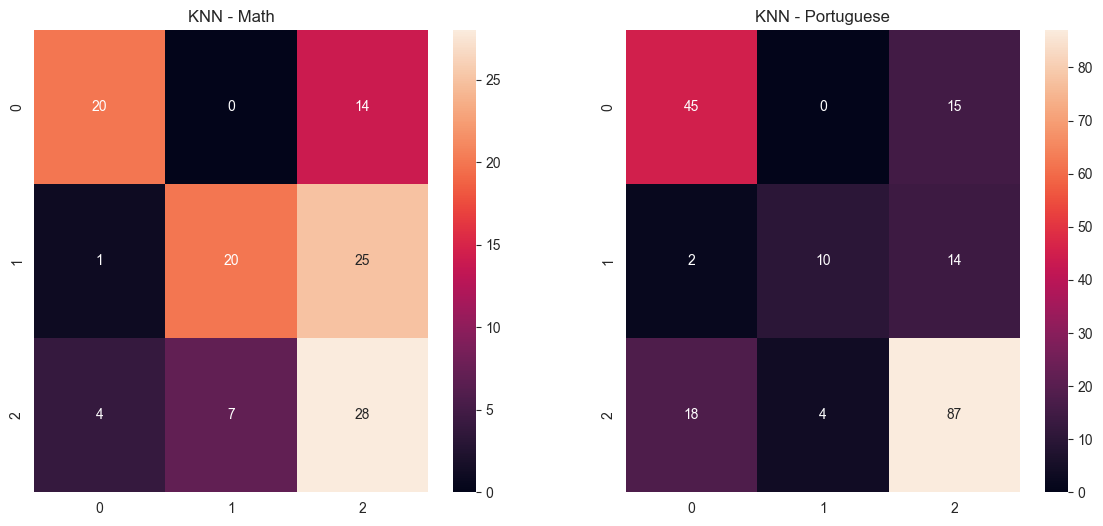

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, (name, result) in zip(axes, knn_results.items()):

    cm = confusion_matrix(
        result["y_test"],
        result["y_pred"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=ax
    )

    ax.set_title(f"KNN - {name}")

plt.show()

## Analyse détaillée : Performance KNN par sous-groupes

Ces cellules percent la performance de KNN selon les variables d'intérêt, pour identifier où le modèle fonctionne mieux ou moins bien.

ANALYSE KNN - CONSOMMATION D'ALCOOL

Math - Alcool en semaine (Dalc):
 Valeur  Accuracy  Count
      1  0.568182     88
      2  0.529412     17
      3  0.625000      8
      4  0.500000      4
      5  1.000000      2

Math - Alcool week-end (Walc):
 Valeur  Accuracy  Count
      1  0.617021     47
      2  0.481481     27
      3  0.521739     23
      4  0.562500     16
      5  0.833333      6

Portuguese - Alcool en semaine (Dalc):
 Valeur  Accuracy  Count
      1  0.721805    133
      2  0.733333     45
      3  0.900000     10
      4  0.666667      3
      5  0.500000      4

Portuguese - Alcool week-end (Walc):
 Valeur  Accuracy  Count
      1  0.777778     72
      2  0.653846     52
      3  0.685714     35
      4  0.814815     27
      5  0.666667      9


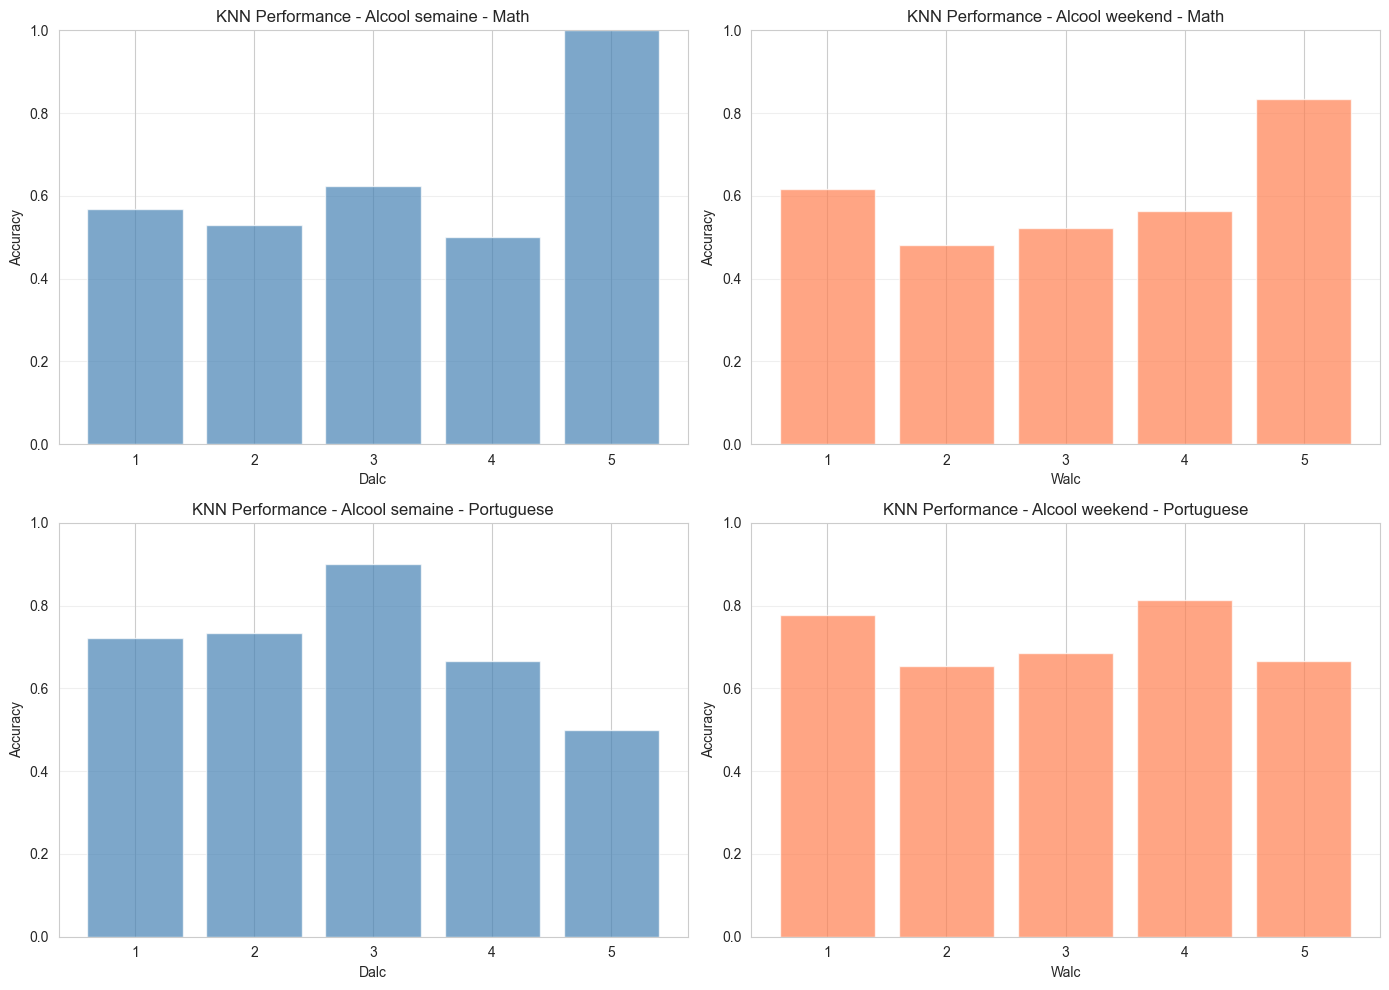

In [17]:
### Fonction d'analyse de performance par sous-groupes

from sklearn.metrics import accuracy_score

def analyse_knn_par_variable(df, variable_name, y_test, y_pred, test_indices):
    """Analyse la performance KNN pour chaque valeur d'une variable"""
    
    # Récupérer les valeurs du variable pour les indices de test
    var_values = df.iloc[test_indices][variable_name].values
    
    # Créer un DataFrame pour l'analyse
    resultats = []
    
    if variable_name in ["Dalc", "Walc", "Medu", "Fedu", "absences"]:
        # Variables numériques
        unique_vals = sorted(df[variable_name].unique())
    else:
        # Variables catégoriques
        unique_vals = df[variable_name].unique()
    
    for val in unique_vals:
        mask = var_values == val
        if mask.sum() > 0:
            acc = accuracy_score(y_test[mask], y_pred[mask])
            count = mask.sum()
            resultats.append({
                "Valeur": val,
                "Accuracy": acc,
                "Count": count
            })
    
    return pd.DataFrame(resultats)

### Analyse pour Alcool

print("=" * 60)
print("ANALYSE KNN - CONSOMMATION D'ALCOOL")
print("=" * 60)

for name, df in [("Math", df_mat), ("Portuguese", df_por)]:
    X = pd.get_dummies(df.drop(columns=["niveau"]), drop_first=True)
    y = df["niveau"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    # Alcool semaine
    print(f"\n{name} - Alcool en semaine (Dalc):")
    test_indices = X_test.index
    analysis_dalc = analyse_knn_par_variable(df, "Dalc", y_test, y_pred, test_indices)
    print(analysis_dalc.to_string(index=False))
    
    # Alcool weekend
    print(f"\n{name} - Alcool week-end (Walc):")
    analysis_walc = analyse_knn_par_variable(df, "Walc", y_test, y_pred, test_indices)
    print(analysis_walc.to_string(index=False))

### Plot performance KNN par Alcool

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pd.get_dummies(df.drop(columns=["niveau"]), drop_first=True)
    y = df["niveau"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    test_indices = X_test.index
    
    # Dalc
    analysis_dalc = analyse_knn_par_variable(df, "Dalc", y_test, y_pred, test_indices)
    axes[ax_idx, 0].bar(analysis_dalc["Valeur"], analysis_dalc["Accuracy"], color="steelblue", alpha=0.7)
    axes[ax_idx, 0].set_title(f"KNN Performance - Alcool semaine - {name}")
    axes[ax_idx, 0].set_xlabel("Dalc")
    axes[ax_idx, 0].set_ylabel("Accuracy")
    axes[ax_idx, 0].set_ylim(0, 1)
    axes[ax_idx, 0].grid(axis='y', alpha=0.3)
    
    # Walc
    analysis_walc = analyse_knn_par_variable(df, "Walc", y_test, y_pred, test_indices)
    axes[ax_idx, 1].bar(analysis_walc["Valeur"], analysis_walc["Accuracy"], color="coral", alpha=0.7)
    axes[ax_idx, 1].set_title(f"KNN Performance - Alcool weekend - {name}")
    axes[ax_idx, 1].set_xlabel("Walc")
    axes[ax_idx, 1].set_ylabel("Accuracy")
    axes[ax_idx, 1].set_ylim(0, 1)
    axes[ax_idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 PRÉAMBULE : L'impact direct des variables sur G3

**Note importante** : "niveau" est dérivé de G3 (la note finale):
- Echec : G3 < 10
- Moyen : 10 ≤ G3 < 14
- Bon : G3 ≥ 14

Donc **prédire "niveau" = prédire si les notes seront bonnes ou mauvaises** en fonction des variables d'intérêt.

IMPACT DIRECT SUR G3 - DISTRIBUTION PAR VARIABLES

MATH

Alcool semaine (Dalc):
         G3               niveau
       mean   std count <lambda>
Dalc                            
1     10.73  4.68   276       83
2      9.25  4.81    75       13
3     10.50  3.44    26        4
4      9.89  2.62     9        0
5     10.67  2.69     9        0


C:\Users\HKHD\AppData\Local\Temp\ipykernel_5884\2018154453.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var_name, y="G3", data=df, ax=ax, palette="Set2")



Alcool weekend (Walc):
         G3               niveau
       mean   std count <lambda>
Walc                            
1     10.74  5.13   151       49
2     10.08  4.95    85       23
3     10.72  3.70    80       19
4      9.69  3.62    51        5
5     10.14  4.13    28        4


C:\Users\HKHD\AppData\Local\Temp\ipykernel_5884\2018154453.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var_name, y="G3", data=df, ax=ax, palette="Set2")



Éducation mère (Medu):
         G3               niveau
       mean   std count <lambda>
Medu                            
0     13.00  3.46     3        2
1      8.68  4.36    59        4
2      9.73  4.64   103       18
3     10.30  4.62    99       23
4     11.76  4.27   131       53


...


Éducation père (Fedu):
         G3               niveau
       mean   std count <lambda>
Fedu                            
0     12.14  2.79     7        1
1     10.94  3.42   174       39
2     11.78  3.45   209       59
3     12.38  2.49   131       41
4     12.92  2.92   128       54


C:\Users\HKHD\AppData\Local\Temp\ipykernel_5884\2018154453.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var_name, y="G3", data=df, ax=ax, palette="Set2")



Absences (absences):
             G3               niveau
           mean   std count <lambda>
absences                            
0         12.04  4.07   244       86
1         12.42  1.88    12        4
2         12.19  2.62   110       32
3         10.43  3.51     7        1
4         12.01  2.43    93       26
5         11.75  2.60    12        3
6         12.12  2.38    49       12
7         13.00  4.36     3        2
8         11.62  2.56    42       12
9          9.71  2.63     7        1
10        12.24  3.13    21        8
11        11.20  0.84     5        0
12        10.08  2.64    12        2
13        14.00   NaN     1        1
14        10.38  3.11     8        1
15        11.00  1.41     2        0
16        10.30  1.49    10        0
18        12.33  2.08     3        1
21        11.50  2.12     2        0
22         8.00  2.83     2        0
24         9.00   NaN     1        0
26         8.00   NaN     1        0
30        16.00   NaN     1        1
32        14.00 

C:\Users\HKHD\AppData\Local\Temp\ipykernel_5884\2018154453.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="absence_quartile", y="G3", data=df_temp, ax=ax, palette="Set2")
C:\Users\HKHD\AppData\Local\Temp\ipykernel_5884\2018154453.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var_name, y="G3", data=df, ax=ax, palette="Set2")


        G3               niveau
      mean   std count <lambda>
sex                            
F    12.25  3.12   383      129
M    11.41  3.32   266       65


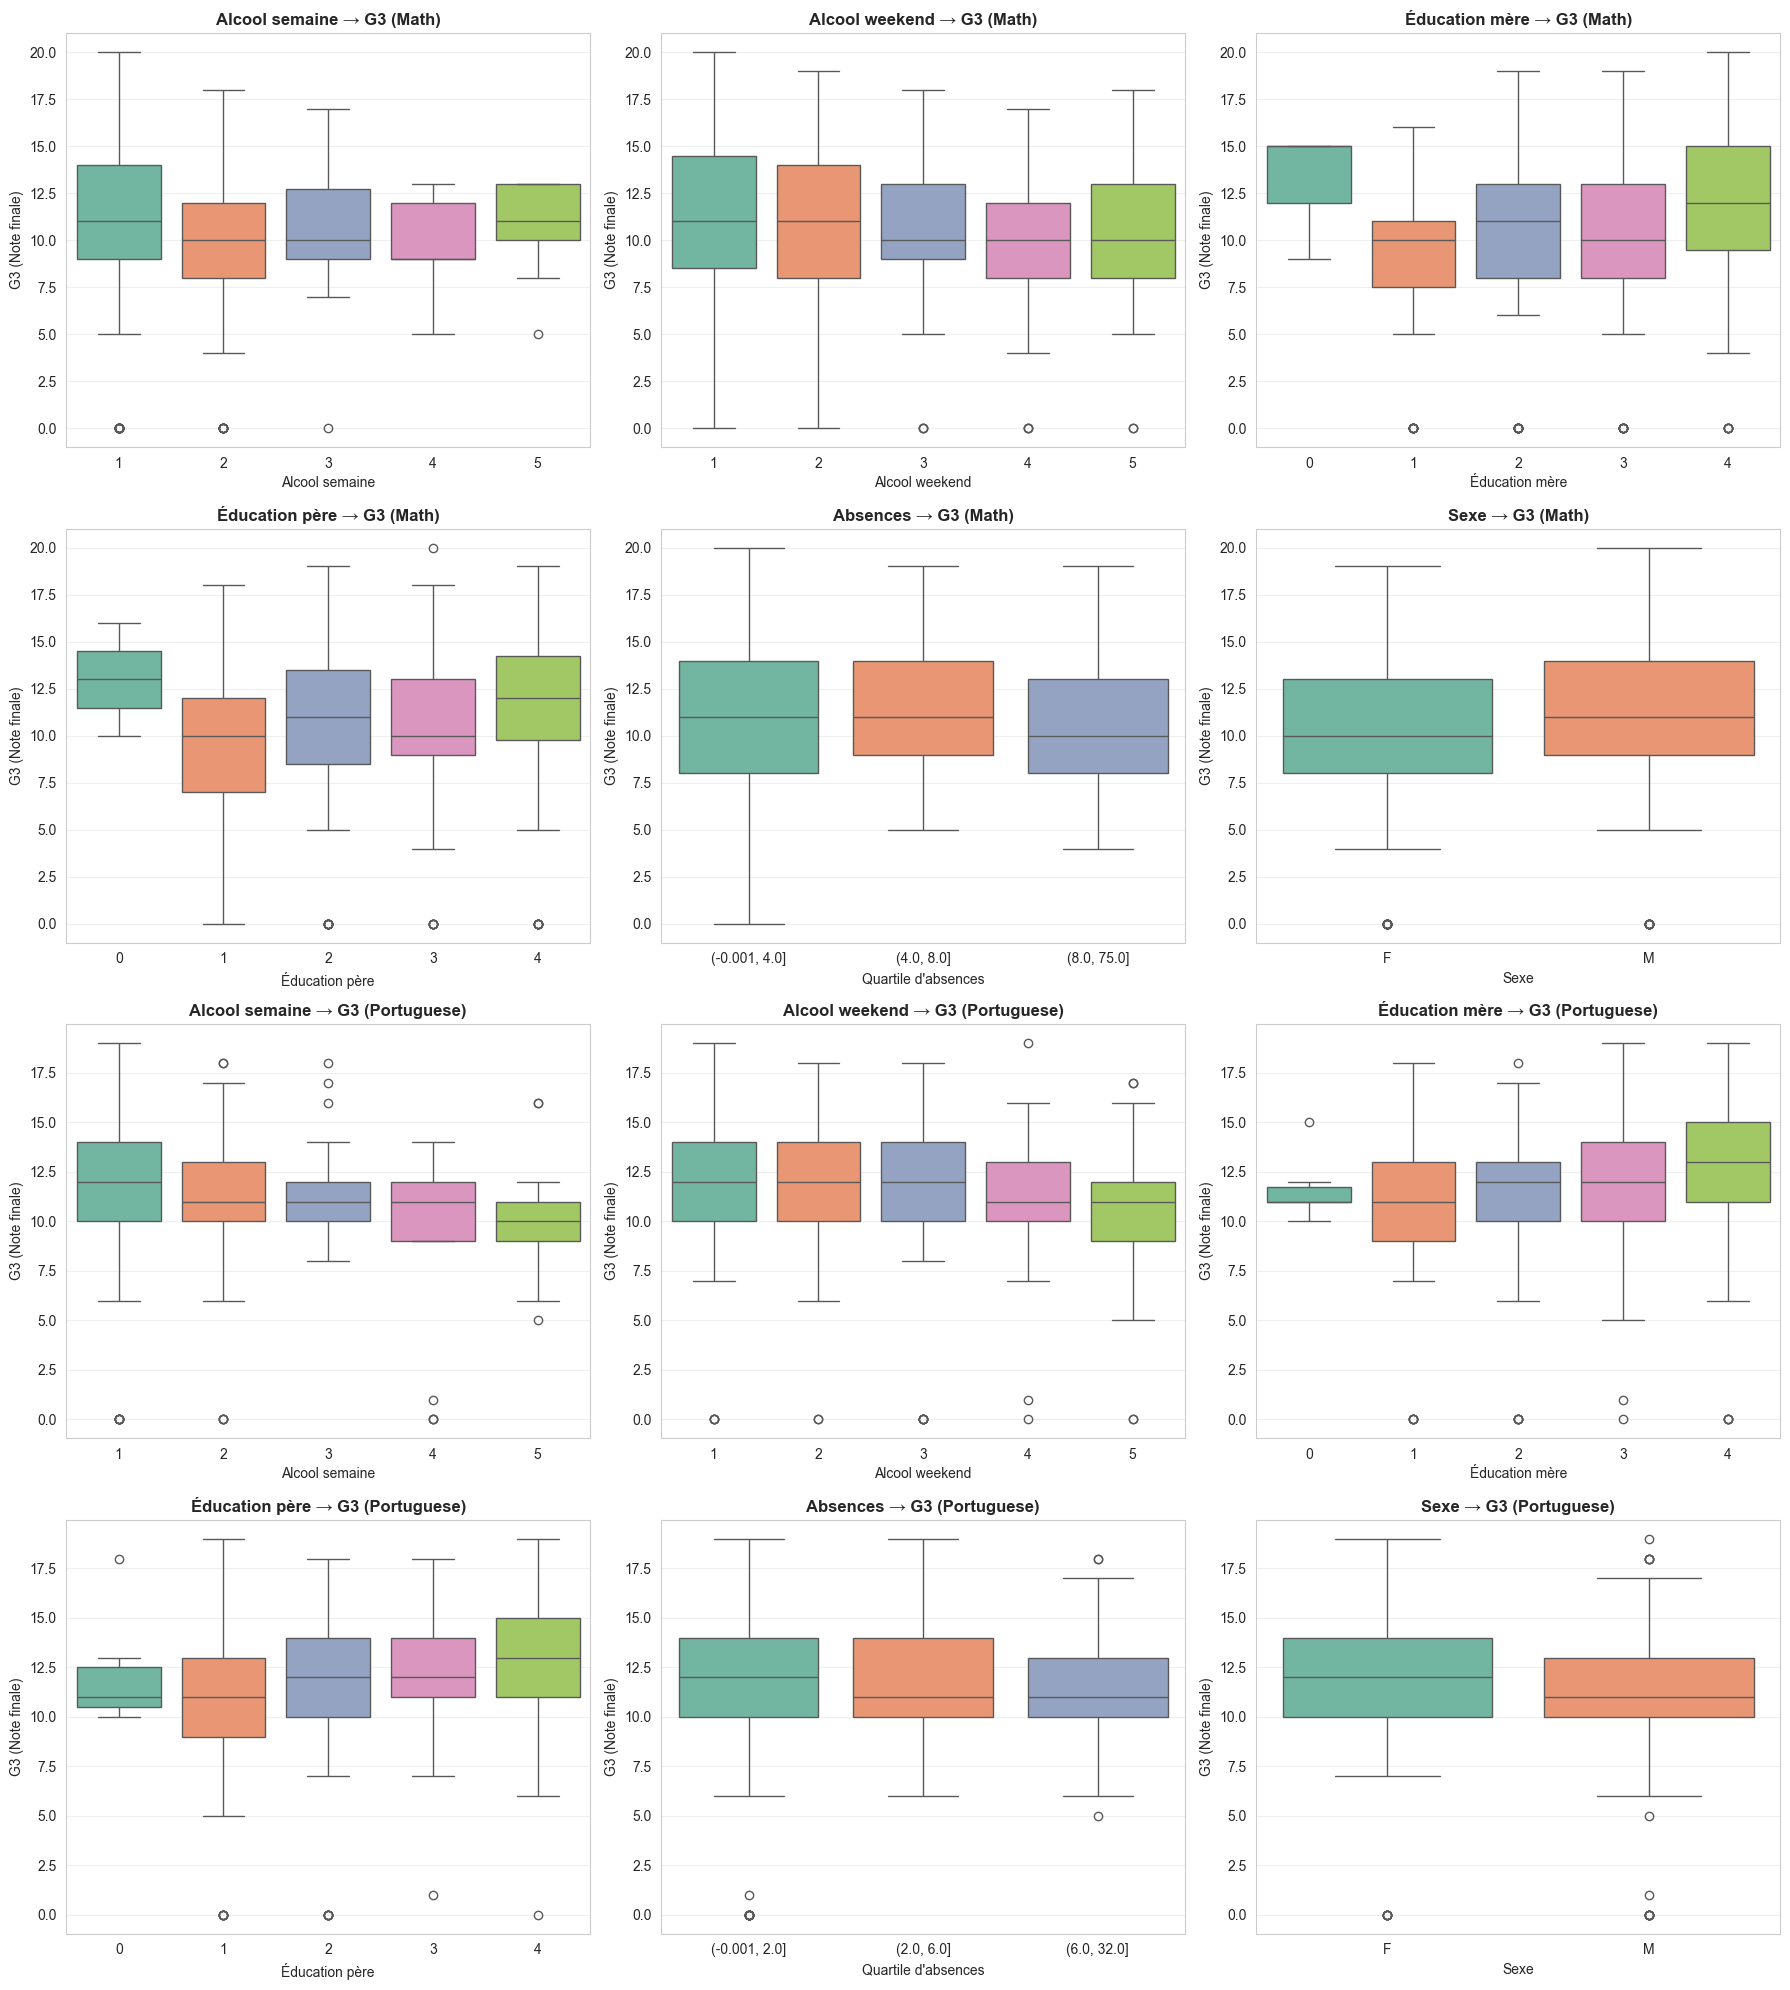

In [18]:
### Distribution de G3 et "niveau" par variables (IMPACT DIRECT)

print("=" * 70)
print("IMPACT DIRECT SUR G3 - DISTRIBUTION PAR VARIABLES")
print("=" * 70)

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

variables_knn = [("Dalc", "Alcool semaine"), ("Walc", "Alcool weekend"), 
                 ("Medu", "Éducation mère"), ("Fedu", "Éducation père"),
                 ("absences", "Absences"), ("sex", "Sexe")]

for plot_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}")
    
    for var_idx, (var_name, var_label) in enumerate(variables_knn):
        row = plot_idx * 2 + var_idx // 3
        col = var_idx % 3
        ax = axes[row, col]
        
        print(f"\n{var_label} ({var_name}):")
        print(df.groupby(var_name)[["G3", "niveau"]].agg({
            "G3": ["mean", "std", "count"],
            "niveau": lambda x: (x == "Bon").sum()  # Count of "Bon"
        }).round(2))
        
        # Boxplot G3 vs variable
        if var_name in ["absences"]:
            # Créer des quartiles pour absences
            df_temp = df.copy()
            df_temp["absence_quartile"] = pd.qcut(df_temp["absences"], q=4, duplicates='drop')
            sns.boxplot(x="absence_quartile", y="G3", data=df_temp, ax=ax, palette="Set2")
            ax.set_xlabel("Quartile d'absences")
        else:
            sns.boxplot(x=var_name, y="G3", data=df, ax=ax, palette="Set2")
            ax.set_xlabel(var_label)
        
        ax.set_ylabel("G3 (Note finale)")
        ax.set_title(f"{var_label} → G3 ({name})", fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


ANALYSE KNN - ÉDUCATION DES PARENTS

Math - Éducation mère (Medu):
 Valeur  Accuracy  Count
      0  0.000000      1
      1  0.700000     20
      2  0.379310     29
      3  0.500000     24
      4  0.688889     45

Math - Éducation père (Fedu):
 Valeur  Accuracy  Count
      0  1.000000      1
      1  0.518519     27
      2  0.620690     29
      3  0.533333     30
      4  0.593750     32

Portuguese - Éducation mère (Medu):
 Valeur  Accuracy  Count
      0  1.000000      4
      1  0.783784     37
      2  0.706897     58
      3  0.675676     37
      4  0.728814     59

Portuguese - Éducation père (Fedu):
 Valeur  Accuracy  Count
      0  1.000000      1
      1  0.689655     58
      2  0.745763     59
      3  0.733333     30
      4  0.744681     47


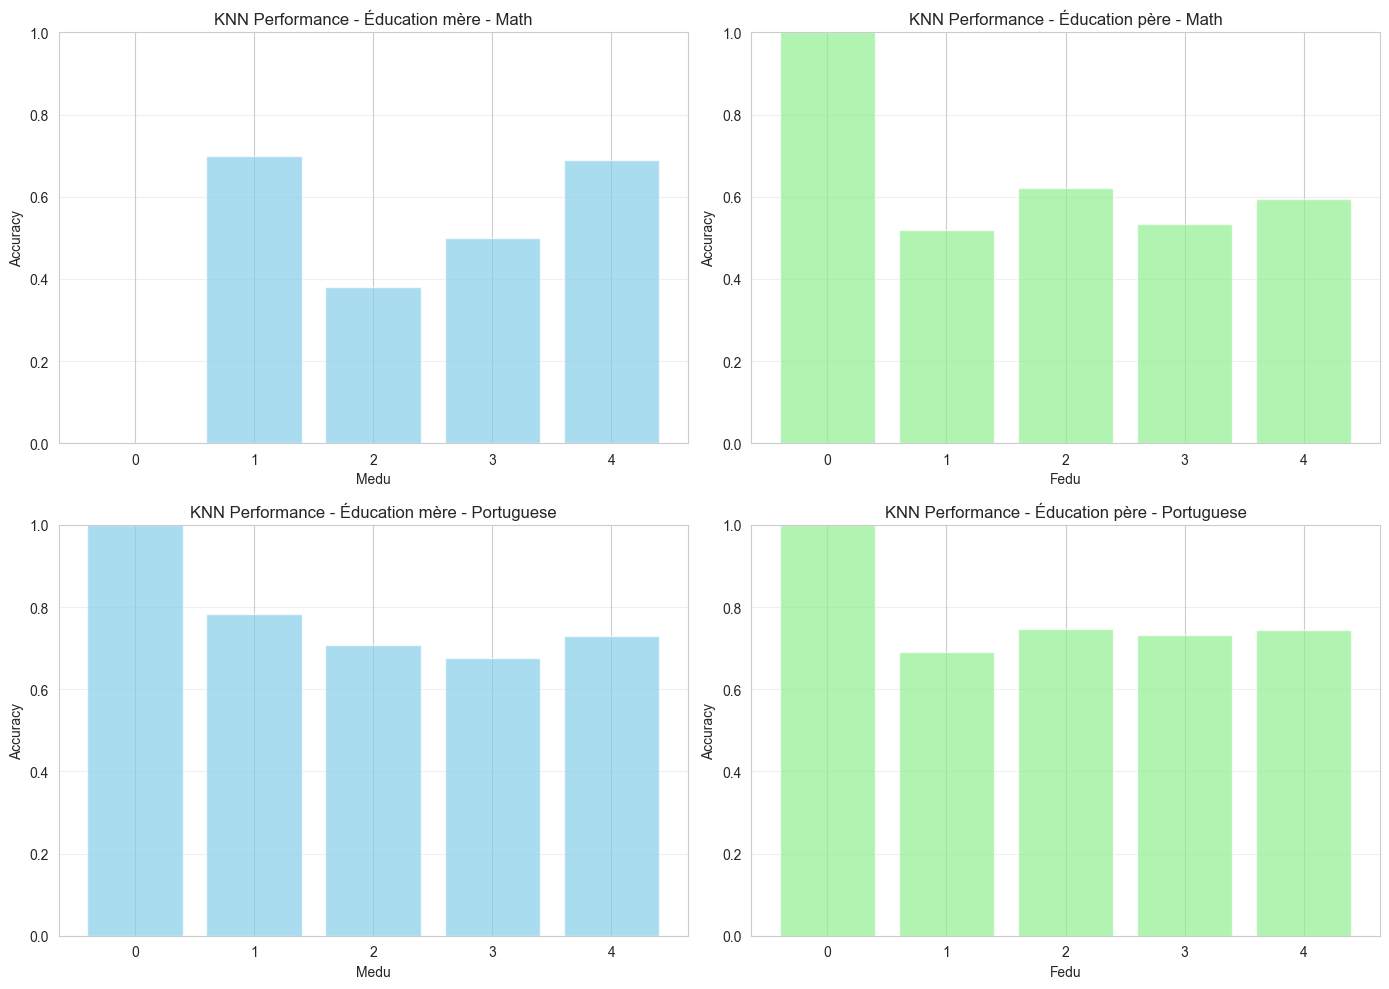


ANALYSE KNN - SEXE ET ABSENCES

Math - Sexe:
Valeur  Accuracy  Count
     F  0.551724     58
     M  0.590164     61

Math - Absences (quartiles):
       Valeur  Accuracy  Count
   (4.0, 8.0]  0.583333     24
(-0.001, 4.0]  0.605634     71
  (8.0, 75.0]  0.458333     24

Portuguese - Sexe:
Valeur  Accuracy  Count
     F  0.752066    121
     M  0.689189     74

Portuguese - Absences (quartiles):
       Valeur  Accuracy  Count
   (2.0, 6.0]  0.604651     43
(-0.001, 2.0]  0.767241    116
  (6.0, 32.0]  0.750000     36


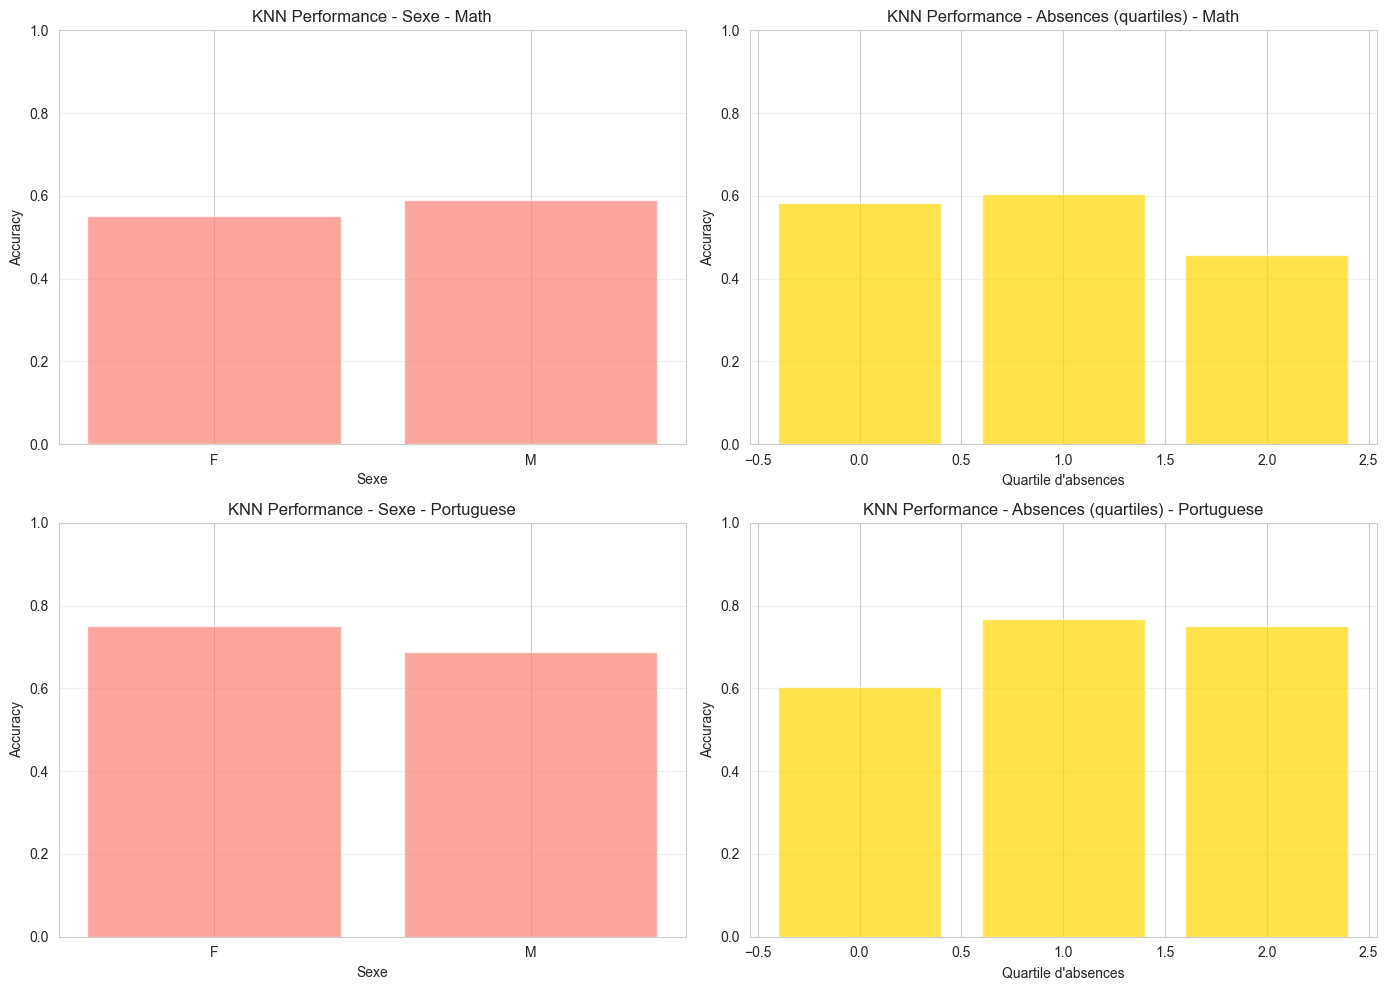

In [19]:
### Analyse pour Éducation des parents

print("\n" + "=" * 60)
print("ANALYSE KNN - ÉDUCATION DES PARENTS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pd.get_dummies(df.drop(columns=["niveau"]), drop_first=True)
    y = df["niveau"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    test_indices = X_test.index
    
    # Medu
    print(f"\n{name} - Éducation mère (Medu):")
    analysis_medu = analyse_knn_par_variable(df, "Medu", y_test, y_pred, test_indices)
    print(analysis_medu.to_string(index=False))
    
    axes[ax_idx, 0].bar(analysis_medu["Valeur"], analysis_medu["Accuracy"], color="skyblue", alpha=0.7)
    axes[ax_idx, 0].set_title(f"KNN Performance - Éducation mère - {name}")
    axes[ax_idx, 0].set_xlabel("Medu")
    axes[ax_idx, 0].set_ylabel("Accuracy")
    axes[ax_idx, 0].set_ylim(0, 1)
    axes[ax_idx, 0].grid(axis='y', alpha=0.3)
    
    # Fedu
    print(f"\n{name} - Éducation père (Fedu):")
    analysis_fedu = analyse_knn_par_variable(df, "Fedu", y_test, y_pred, test_indices)
    print(analysis_fedu.to_string(index=False))
    
    axes[ax_idx, 1].bar(analysis_fedu["Valeur"], analysis_fedu["Accuracy"], color="lightgreen", alpha=0.7)
    axes[ax_idx, 1].set_title(f"KNN Performance - Éducation père - {name}")
    axes[ax_idx, 1].set_xlabel("Fedu")
    axes[ax_idx, 1].set_ylabel("Accuracy")
    axes[ax_idx, 1].set_ylim(0, 1)
    axes[ax_idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Analyse pour Sexe et Absences

print("\n" + "=" * 60)
print("ANALYSE KNN - SEXE ET ABSENCES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax_idx, (name, df) in enumerate([("Math", df_mat), ("Portuguese", df_por)]):
    X = pd.get_dummies(df.drop(columns=["niveau"]), drop_first=True)
    y = df["niveau"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    test_indices = X_test.index
    
    # Sexe
    print(f"\n{name} - Sexe:")
    analysis_sex = analyse_knn_par_variable(df, "sex", y_test, y_pred, test_indices)
    print(analysis_sex.to_string(index=False))
    
    axes[ax_idx, 0].bar(analysis_sex["Valeur"].astype(str), analysis_sex["Accuracy"], color="salmon", alpha=0.7)
    axes[ax_idx, 0].set_title(f"KNN Performance - Sexe - {name}")
    axes[ax_idx, 0].set_xlabel("Sexe")
    axes[ax_idx, 0].set_ylabel("Accuracy")
    axes[ax_idx, 0].set_ylim(0, 1)
    axes[ax_idx, 0].grid(axis='y', alpha=0.3)
    
    # Absences
    print(f"\n{name} - Absences (quartiles):")
    df_temp = df.copy()
    df_temp["absence_quartile"] = pd.qcut(df_temp["absences"], q=4, duplicates='drop')
    analysis_abs = analyse_knn_par_variable(df_temp, "absence_quartile", y_test, y_pred, test_indices)
    print(analysis_abs.to_string(index=False))
    
    axes[ax_idx, 1].bar(range(len(analysis_abs)), analysis_abs["Accuracy"], color="gold", alpha=0.7)
    axes[ax_idx, 1].set_title(f"KNN Performance - Absences (quartiles) - {name}")
    axes[ax_idx, 1].set_xlabel("Quartile d'absences")
    axes[ax_idx, 1].set_ylabel("Accuracy")
    axes[ax_idx, 1].set_ylim(0, 1)
    axes[ax_idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()